# Fashion-MNIST classifier

In [13]:
import sys
sys.path.append('..')

from src.utils import load_fashion_mnist, plot_examples, train_val_split
from src.model import NeuralNetwork

## Load and inspect the data

In [14]:
x_train, x_test, y_train, y_test = load_fashion_mnist()
x_train, x_val, y_train, y_val = train_val_split(x_train, y_train)
print(x_train.shape, x_test.shape)

(784, 50000) (784, 10000)


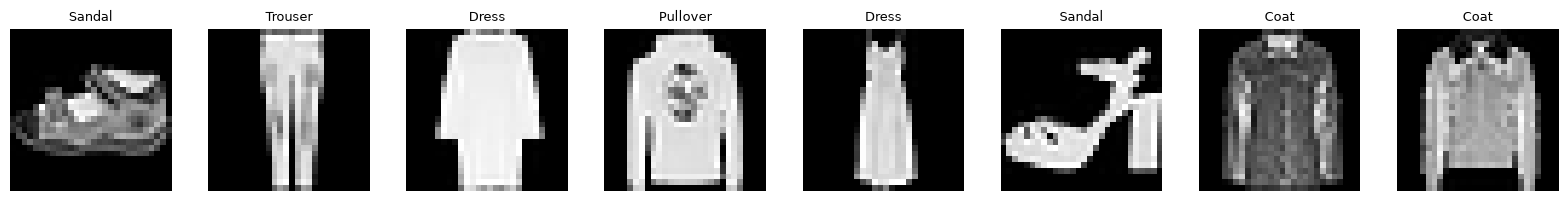

In [15]:
plot_examples(x_train, y_train)

## Train

In [16]:
model = NeuralNetwork(layer_dims=[784, 64, 32, 10])
train_costs, val_costs = model.train(
    x_train, y_train, x_val, y_val, patience=3, n_classes=10,
    epochs=30, batch_size=64, learning_rate=0.1
)

Epoch 0: cost = 0.6394
Epoch 5: cost = 0.3412


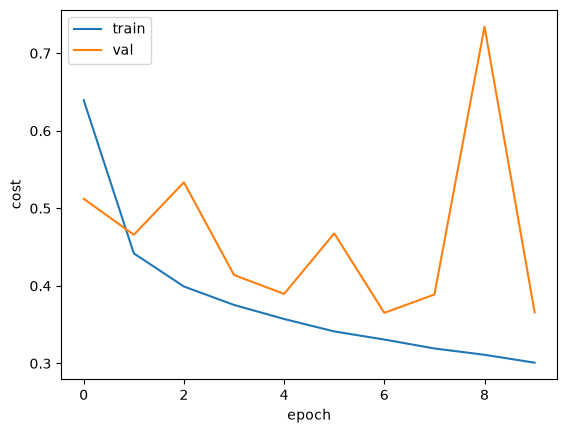

In [17]:
import matplotlib.pyplot as plt

plt.plot(train_costs, label='train')
plt.plot(val_costs, label='val')
plt.xlabel('epoch')
plt.ylabel('cost')
plt.legend()
plt.show()

## Evaluate

In [18]:
preds = model.predict(x_test)
accuracy = (preds == y_test).mean()
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.8605
